In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [2]:
matches = pd.read_csv("data/matches.csv")
deliveries = pd.read_csv("data/deliveries.csv")

print(matches.shape)
print(deliveries.shape)

matches.head()

(1095, 20)
(260920, 17)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
top_runs = (
    deliveries.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_runs)

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


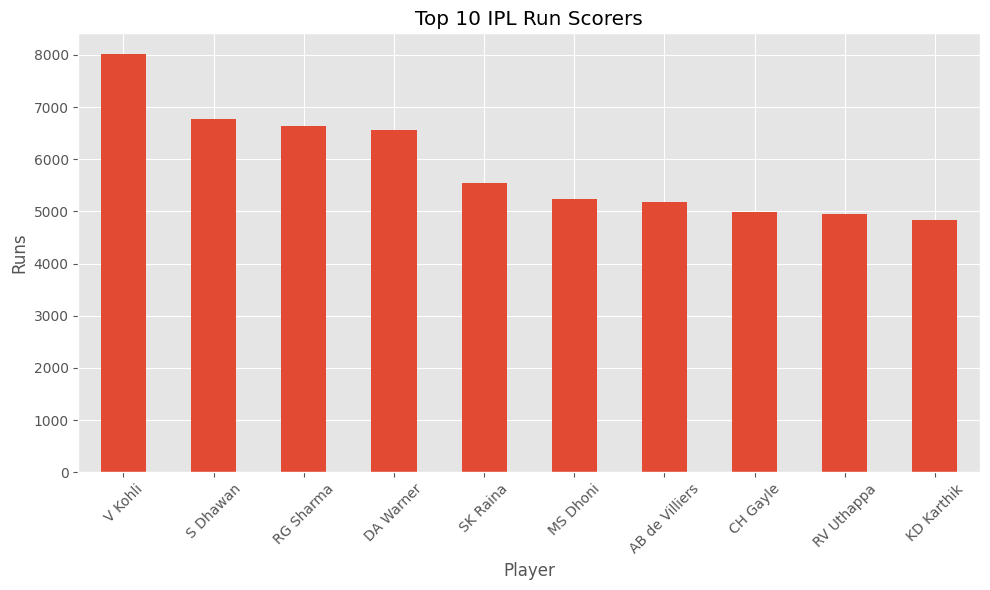

In [4]:
plt.figure(figsize=(10,6))
top_runs.plot(kind='bar')

plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Player")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [5]:
player_stats = deliveries.groupby('batter').agg(
    Runs=('batsman_runs', 'sum'),
    Balls=('ball', 'count')
)

player_stats = player_stats[player_stats['Balls'] >= 500]

player_stats['Strike Rate'] = (
    player_stats['Runs'] /
    player_stats['Balls']
) * 100

top_sr = player_stats.sort_values(
    by='Strike Rate',
    ascending=False
).head(10)

print(top_sr)

                 Runs  Balls  Strike Rate
batter                                   
AD Russell       2488   1515   164.224422
H Klaasen         993    613   161.990212
SP Narine        1534    984   155.894309
N Pooran         1769   1143   154.768154
LS Livingstone    939    609   154.187192
GJ Maxwell       2772   1842   150.488599
RM Patidar        799    534   149.625468
Abhishek Sharma  1377    925   148.864865
V Sehwag         2728   1833   148.827059
AB de Villiers   5181   3487   148.580442


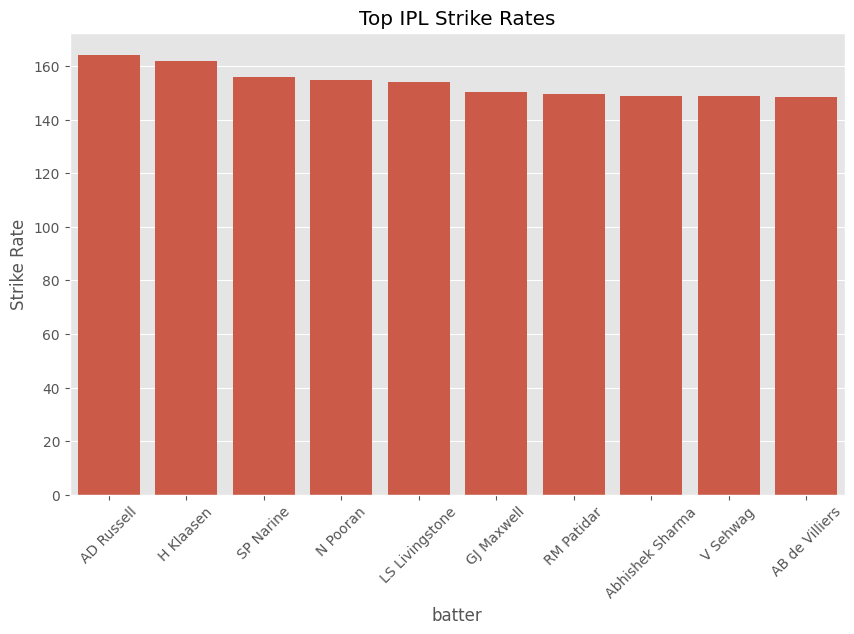

In [6]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_sr.index,
    y=top_sr['Strike Rate']
)

plt.title("Top IPL Strike Rates")
plt.xticks(rotation=45)

plt.show()

In [7]:
wins = matches['winner'].value_counts()

team_matches = pd.concat([
    matches['team1'],
    matches['team2']
]).value_counts()

team_stats = pd.DataFrame({
    'Matches Played': team_matches,
    'Wins': wins
}).fillna(0)

team_stats['Win %'] = (
    team_stats['Wins'] /
    team_stats['Matches Played']
) * 100

team_stats = team_stats.sort_values(
    by='Win %',
    ascending=False
)

print(team_stats)

                             Matches Played  Wins      Win %
Rising Pune Supergiant                   16    10  62.500000
Gujarat Titans                           45    28  62.222222
Chennai Super Kings                     238   138  57.983193
Mumbai Indians                          261   144  55.172414
Lucknow Super Giants                     44    24  54.545455
Delhi Capitals                           91    48  52.747253
Kolkata Knight Riders                   251   131  52.191235
Rajasthan Royals                        221   112  50.678733
Sunrisers Hyderabad                     182    88  48.351648
Royal Challengers Bangalore             240   116  48.333333
Royal Challengers Bengaluru              15     7  46.666667
Kings XI Punjab                         190    88  46.315789
Gujarat Lions                            30    13  43.333333
Punjab Kings                             56    24  42.857143
Kochi Tuskers Kerala                     14     6  42.857143
Delhi Daredevils        

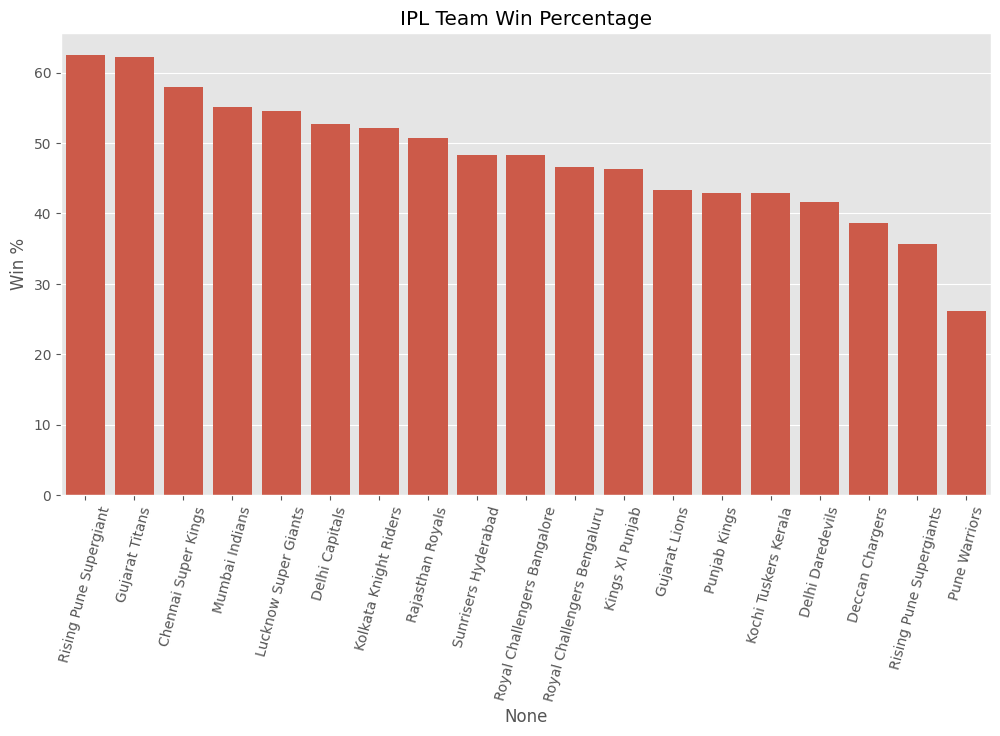

In [8]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=team_stats.index,
    y=team_stats['Win %']
)

plt.title("IPL Team Win Percentage")
plt.xticks(rotation=75)

plt.show()

In [9]:
match_season = matches[['id', 'season']]

merged = deliveries.merge(
    match_season,
    left_on='match_id',
    right_on='id'
)

merged.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,2007/08
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,2007/08
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08


In [10]:
season_runs = (
    merged.groupby(['season', 'batter'])
    ['batsman_runs']
    .sum()
    .reset_index()
)

orange_caps = season_runs.loc[
    season_runs.groupby('season')
    ['batsman_runs']
    .idxmax()
]

orange_caps = orange_caps.sort_values('season')

print(orange_caps)

       season         batter  batsman_runs
115   2007/08       SE Marsh           616
229      2009      ML Hayden           572
446   2009/10   SR Tendulkar           618
502      2011       CH Gayle           608
684      2012       CH Gayle           733
910      2013     MEK Hussey           733
1088     2014     RV Uthappa           660
1148     2015      DA Warner           562
1383     2016        V Kohli           973
1422     2017      DA Warner           641
1594     2018  KS Williamson           735
1694     2019      DA Warner           692
1866  2020/21       KL Rahul           676
2051     2021     RD Gaikwad           635
2144     2022     JC Buttler           863
2423     2023   Shubman Gill           890
2606     2024        V Kohli           741


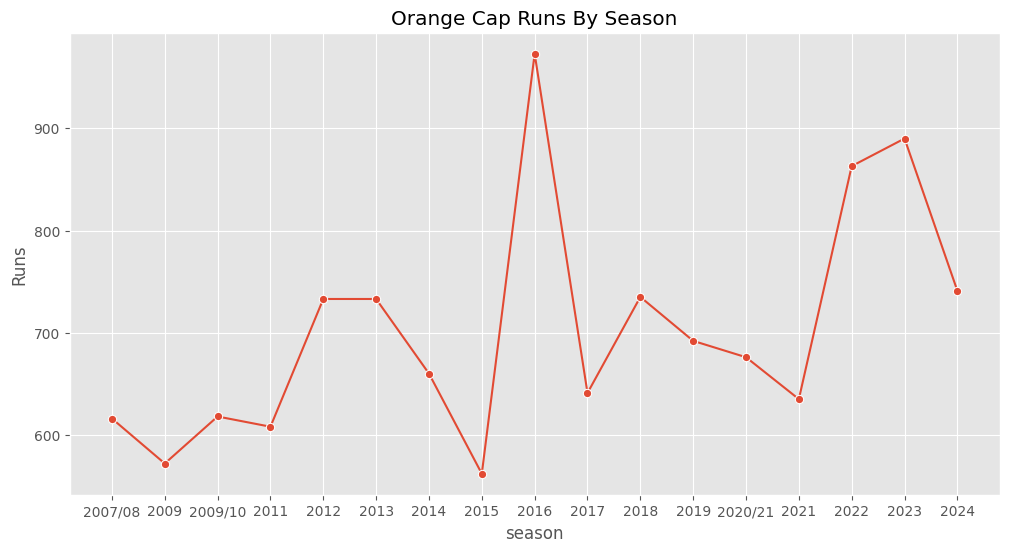

In [11]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=orange_caps,
    x='season',
    y='batsman_runs',
    marker='o'
)

plt.title("Orange Cap Runs By Season")
plt.ylabel("Runs")

plt.show()

In [12]:
virat = merged[
    merged['batter'] == 'V Kohli'
]

virat_season = (
    virat.groupby('season')
    ['batsman_runs']
    .sum()
    .reset_index()
)

print(virat_season)

     season  batsman_runs
0   2007/08           165
1      2009           246
2   2009/10           307
3      2011           557
4      2012           364
5      2013           639
6      2014           359
7      2015           505
8      2016           973
9      2017           308
10     2018           530
11     2019           464
12  2020/21           471
13     2021           405
14     2022           341
15     2023           639
16     2024           741


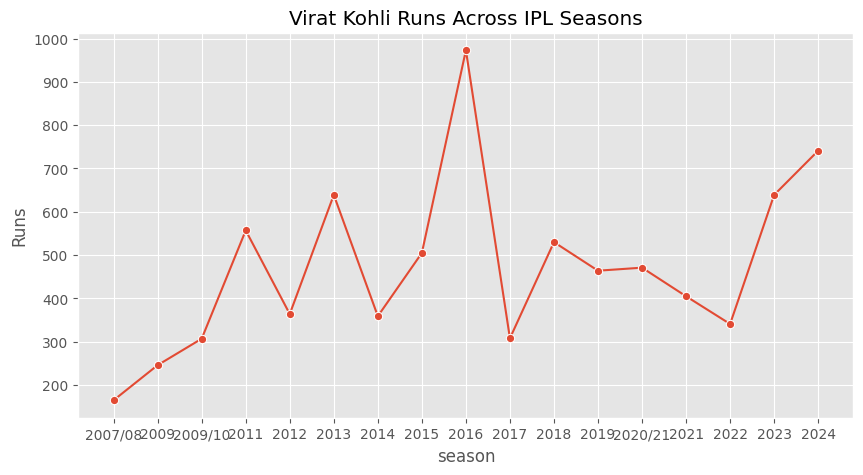

In [13]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=virat_season,
    x='season',
    y='batsman_runs',
    marker='o'
)

plt.title("Virat Kohli Runs Across IPL Seasons")
plt.ylabel("Runs")

plt.show()

In [14]:
orange_caps.to_csv(
    "orange_cap_winners.csv",
    index=False
)

team_stats.to_csv(
    "team_win_rates.csv"
)

print("Files exported successfully.")

Files exported successfully.


In [15]:
players = [
    'V Kohli',
    'RG Sharma',
    'DA Warner',
    'MS Dhoni',
    'AB de Villiers'
]

player_comparison = merged[
    merged['batter'].isin(players)
]

season_runs = (
    player_comparison
    .groupby(['season', 'batter'])['batsman_runs']
    .sum()
    .reset_index()
)

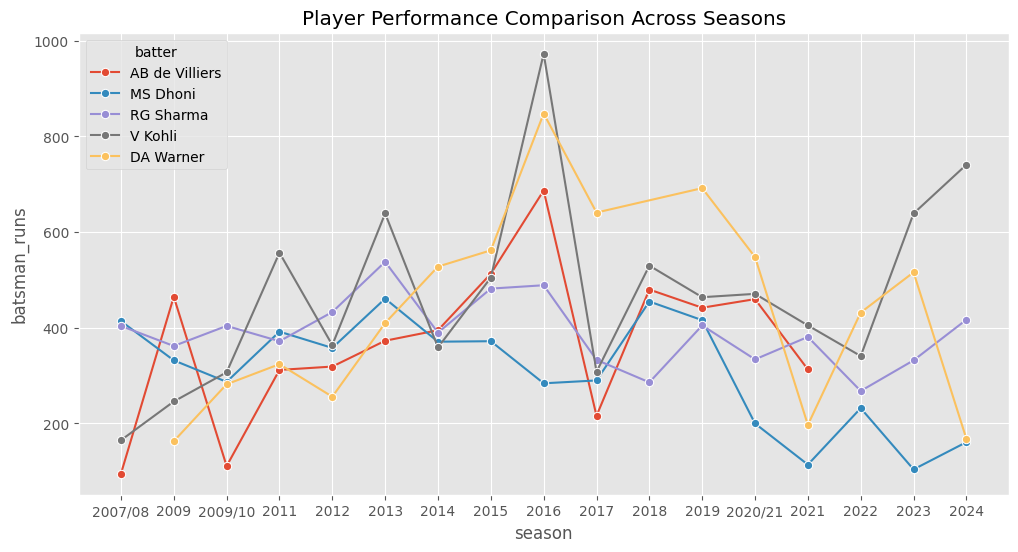

In [16]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=season_runs,
    x='season',
    y='batsman_runs',
    hue='batter',
    marker='o'
)

plt.title('Player Performance Comparison Across Seasons')
plt.show()